In [1]:
from MeravErez.filenames import *
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import scipy
import pickle as pkl

In [2]:
latest_filename = '/home/data/permed/unified/dataframe/20210923/df_q_unified_pilot12_20210923.csv'
df = pd.read_csv(latest_filename, low_memory=False)
hr = pkl.load(open(hr_agg_filename_grace_cont_14d, 'rb'))
    
with open('v3_participant_nums.pkl', 'rb') as f:
    v3_participant_nums = pkl.load(f)

# Compute Questionnaire Compliance

In [3]:
df = df[df['participant_num'].isin(v3_participant_nums[3])]

In [4]:
df['participant_num'].nunique()

1179

In [5]:
around_3rd_vaccine = df[df['days_from_q_to_third'].isin(np.arange(-7, 7))]

In [6]:
q_compliance_3 = around_3rd_vaccine.groupby('days_from_q_to_third')['participant_num'].nunique()

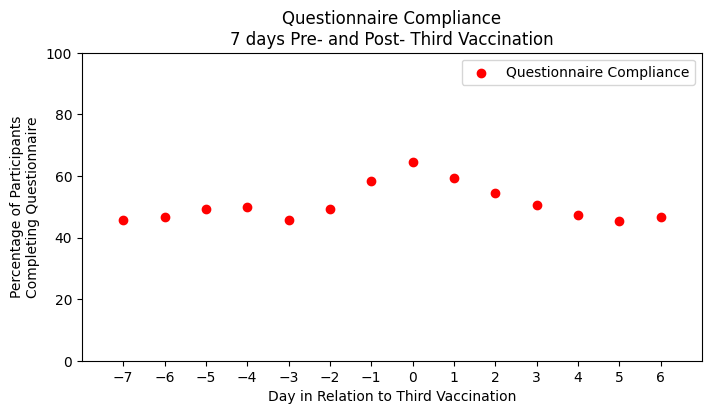

In [7]:
fig = plt.figure(figsize=(8, 4), facecolor='white')
plt.scatter(q_compliance_3.index, 100* np.array(q_compliance_3.values) / 1179, color='red', label='Questionnaire Compliance')
plt.xlim((-8, 7))
plt.ylim((0, 100))
plt.xticks(np.arange(-7,7))
plt.ylabel("Percentage of Participants\nCompleting Questionnaire")
plt.xlabel("Day in Relation to Third Vaccination")
plt.title("Questionnaire Compliance\n7 days Pre- and Post- Third Vaccination")
plt.legend()
plt.show()

In [8]:
def compliance_in_days(days):
    compliance = df[df['days_from_q_to_third'].isin(days)]['participant_num'].nunique()
    print("Compliance in days %d to %d is %d (%.2f)" % (min(days),
                                                        max(days),
                                                        compliance,
                                                        compliance / 1179))

compliance_in_days([-6, -5, -4])
compliance_in_days([-3, -2, -1])
compliance_in_days([0, 1, 2])
compliance_in_days([3, 4, 5])

Compliance in days -6 to -4 is 999 (0.85)
Compliance in days -3 to -1 is 1047 (0.89)
Compliance in days 0 to 2 is 1179 (1.00)
Compliance in days 3 to 5 is 965 (0.82)


# Compute Garmin compliance

Percentage of day that participants wear the smartwatch among participants who recorded any smartwatch data between -7 days prior to and post vaccination

In [9]:
missing_all_data_parts = list()

for part in hr['third'].keys():
    full_data = np.array(hr['third'][part]['hourly_raw'][24*7:24*21])
    if np.count_nonzero(~np.isnan(full_data)) == 0:
        missing_all_data_parts.append(part)

print("There were %d participants whose entire Garmin data was null." % (len(missing_all_data_parts)))

There were 51 participants whose entire Garmin data was null.


In [10]:
day_to_not_nans = dict()

for day in np.arange(-7, 7):
    day_to_not_nans[day] = list()

for part in hr['third'].keys():
    if part not in missing_all_data_parts:
        for day in np.arange(-7, 7):
            data = np.array(hr['third'][part]['hourly_raw'][24*(day+14):24*(day+15)])
            day_to_not_nans[day].append(np.count_nonzero(~np.isnan(data)))

In [11]:
to_plot = list()

for day in np.arange(-7,7):
    to_plot.append(100/24 * np.mean(day_to_not_nans[day]))

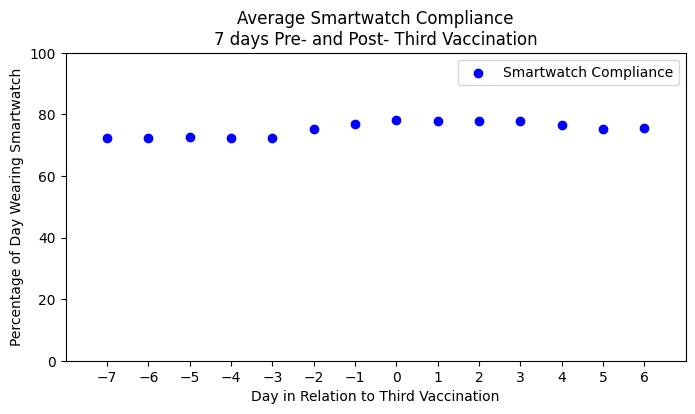

In [12]:
fig = plt.figure(figsize=(8, 4), facecolor='white')
plt.scatter(np.arange(-7,7), to_plot, color='blue', label='Smartwatch Compliance')
plt.xlim((-8, 7))
plt.ylim((0, 100))
plt.xticks(np.arange(-7,7))
plt.ylabel("Percentage of Day Wearing Smartwatch")
plt.xlabel("Day in Relation to Third Vaccination")
plt.title("Average Smartwatch Compliance\n7 days Pre- and Post- Third Vaccination")
plt.legend()
plt.show()